# Deliverable 2: Regression Modeling and Performance Evaluation

## Advanced Data Mining Project

Dataset: `ecommerce_user_dataset_cleaned.csv`

This notebook covers:

- Feature engineering to improve predictive signals
- Building multiple regression models
- Model evaluation using R-squared, MSE, and RMSE
- Cross-validation for generalization assessment
- Comparative visualizations and final model insights


In [2]:
# Core scientific stack
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional plotting style package
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Scikit-learn components for preprocessing, modeling, and validation
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print('Environment ready. Seaborn available:', HAS_SEABORN)

Environment ready. Seaborn available: True


In [10]:
# 1) Load data and inspect structure
file_path = 'ecommerce_user_dataset_cleaned.csv'
df = pd.read_csv(file_path)

print('Shape (rows, columns):', df.shape)
print('Columns:', df.columns.tolist())
display(df.head())
display(df.describe(include='all').T)

Shape (rows, columns): (1000, 8)
Columns: ['Customer_ID', 'Purchase_History', 'Transaction_Frequency', 'Monetary_Value', 'Browsing_Behavior', 'Engagement_Score', 'Time_on_Site', 'Customer_Segment']


,Customer_ID,Purchase_History,Transaction_Frequency,Monetary_Value,Browsing_Behavior,Engagement_Score,Time_on_Site,Customer_Segment
0,CUST0001,23,0.2577,664.0900,88.1000,0.2600,11.8400,Iron
1,CUST0002,15,0.3785,"4,244.2100",5.8700,0.2800,35.0400,Copp
2,CUST0003,21,2.5781,"4,638.4700",23.8800,0.9300,10.1400,Copp
3,CUST0004,25,1.7498,"7,277.5600",89.8400,0.0200,22.0200,Iron
4,CUST0005,15,1.3223,"5,785.4500",26.3600,0.7000,42.1200,Copp


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,1000,1000,CUST0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_History,"1,000.0000",NaN,NaN,NaN,19.8790,4.5615,8.0000,17.0000,20.0000,23.0000,32.0000
Transaction_Frequency,"1,000.0000",NaN,NaN,NaN,4.6869,4.1306,0.0001,1.4262,3.4695,6.8135,14.8943
Monetary_Value,"1,000.0000",NaN,NaN,NaN,"4,926.2117","2,819.0933",100.3000,"2,455.9975","4,890.7250","7,311.5775","9,995.6200"
Browsing_Behavior,"1,000.0000",NaN,NaN,NaN,50.2197,28.4882,1.0200,25.9775,48.7500,75.3825,99.8800
Engagement_Score,"1,000.0000",NaN,NaN,NaN,0.4997,0.2927,0.0000,0.2400,0.5000,0.7600,1.0000
Time_on_Site,"1,000.0000",NaN,NaN,NaN,29.8492,16.7392,1.0100,15.4925,29.3800,44.1450,59.9500
Customer_Segment,1000,2,Copp,718,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Target Variable and Feature Engineering Strategy

For regression, we predict **`Monetary_Value`** as a continuous outcome.

Feature engineering focuses on behavior intensity and interaction patterns:

- `purchase_freq_interaction`: captures combined buying tendency
- `engagement_time_interaction`: captures depth of attention
- `browsing_per_visit`: normalizes browsing by transaction frequency
- `purchase_per_visit`: normalizes purchase history by transaction frequency

`Customer_ID` is excluded because it behaves like an identifier, not a meaningful predictive signal.


In [17]:
# 2) Feature engineering
df_model = df.copy()

# Engineered features designed to add behavioral context
df_model['purchase_freq_interaction'] = df_model['Purchase_History'] * \
    df_model['Transaction_Frequency']
df_model['engagement_time_interaction'] = df_model['Engagement_Score'] * \
    df_model['Time_on_Site']
df_model['browsing_per_visit'] = df_model['Browsing_Behavior'] / \
    (df_model['Transaction_Frequency'] + 1)
df_model['purchase_per_visit'] = df_model['Purchase_History'] / \
    (df_model['Transaction_Frequency'] + 1)

target_col = 'Monetary_Value'

numeric_features = [
    'Purchase_History',
    'Transaction_Frequency',
    'Browsing_Behavior',
    'Engagement_Score',
    'Time_on_Site',
    'purchase_freq_interaction',
    'engagement_time_interaction',
    'browsing_per_visit',
    'purchase_per_visit'
]
categorical_features = ['Customer_Segment']

X = df_model[numeric_features + categorical_features]
y = df_model[target_col]

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
display(X.head())

Feature matrix shape: (1000, 10)
Target shape: (1000,)


,Purchase_History,Transaction_Frequency,Browsing_Behavior,Engagement_Score,Time_on_Site,purchase_freq_interaction,engagement_time_interaction,browsing_per_visit,purchase_per_visit,Customer_Segment
0,23,0.2577,88.1000,0.2600,11.8400,5.9261,3.0784,70.0509,18.2880,Iron
1,15,0.3785,5.8700,0.2800,35.0400,5.6772,9.8112,4.2583,10.8816,Copp
2,21,2.5781,23.8800,0.9300,10.1400,54.1407,9.4302,6.6739,5.8690,Copp
3,25,1.7498,89.8400,0.0200,22.0200,43.7462,0.4404,32.6709,9.0914,Iron
4,15,1.3223,26.3600,0.7000,42.1200,19.8350,29.4840,11.3507,6.4590,Copp


In [23]:
# 3) Train-test split
# A fixed random_state ensures reproducibility for fair model comparison.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

Train shape: (800, 10) (800,)
Test shape: (200, 10) (200,)


In [28]:
# 4) Build preprocessing pipeline
# Numeric: median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: most-frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 5) Define multiple regression models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=42)
}

results = []
predictions = {}

# 6) Fit/evaluate each model on holdout test data and with cross-validation
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train on training fold
    pipeline.fit(X_train, y_train)

    # Holdout prediction
    y_pred = pipeline.predict(X_test)
    predictions[model_name] = y_pred

    # Holdout metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation metrics to assess generalization
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            'r2': 'r2',
            'rmse': 'neg_root_mean_squared_error'
        },
        return_train_score=False
    )

    cv_r2_mean = cv_scores['test_r2'].mean()
    cv_rmse_mean = -cv_scores['test_rmse'].mean()

    results.append({
        'Model': model_name,
        'Test_R2': r2,
        'Test_MSE': mse,
        'Test_RMSE': rmse,
        'CV_R2_Mean': cv_r2_mean,
        'CV_RMSE_Mean': cv_rmse_mean
    })

results_df = pd.DataFrame(results).sort_values(
    by='CV_RMSE_Mean').reset_index(drop=True)
display(results_df)

,Model,Test_R2,Test_MSE,Test_RMSE,CV_R2_Mean,CV_RMSE_Mean
0,Ridge,0.2055,"5,936,227.9148","2,436.4375",0.2130,"2,493.0661"
1,Lasso,0.2053,"5,937,183.2230","2,436.6336",0.2129,"2,493.3083"
2,LinearRegression,0.2053,"5,937,181.0478","2,436.6331",0.2129,"2,493.3086"


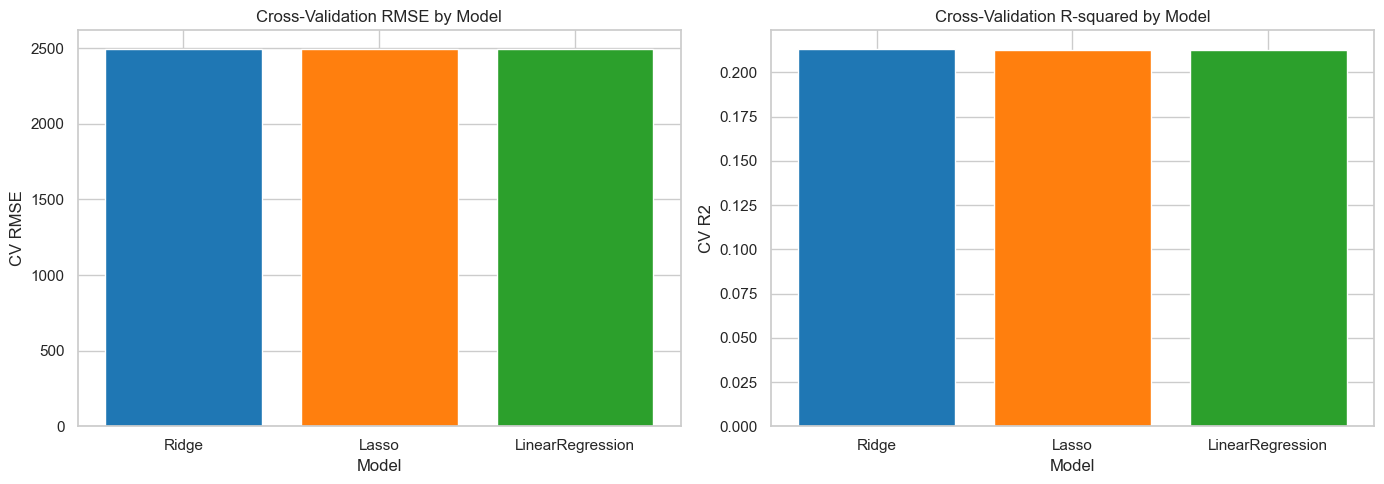

In [32]:
# 7) Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot CV RMSE (lower is better)
axes[0].bar(results_df['Model'], results_df['CV_RMSE_Mean'],
            color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Cross-Validation RMSE by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('CV RMSE')

# Plot CV R2 (higher is better)
axes[1].bar(results_df['Model'], results_df['CV_R2_Mean'],
            color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Cross-Validation R-squared by Model')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('CV R2')

plt.tight_layout()
plt.show()

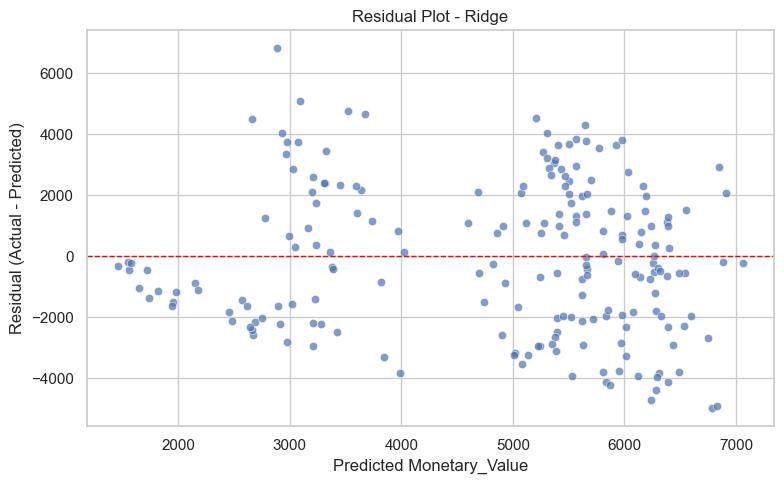

In [33]:
# 8) Residual plot for the best model by CV RMSE
best_model_name = results_df.loc[0, 'Model']
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))
if HAS_SEABORN:
    sns.scatterplot(x=best_pred, y=residuals, alpha=0.7)
else:
    plt.scatter(best_pred, residuals, alpha=0.7)

plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title(f'Residual Plot - {best_model_name}')
plt.xlabel('Predicted Monetary_Value')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

## 2. Model Evaluation Summary

Use the displayed metrics table and plots to identify the strongest model.

Interpretation guide:

- Better **R-squared** means more variance explained
- Lower **MSE/RMSE** means lower prediction error
- Cross-validation metrics indicate expected generalization performance


In [35]:
# 9) Auto-generate concise conclusions from computed metrics
best_row = results_df.iloc[0]

print('Best model by CV RMSE:', best_row['Model'])
print(f"Test R2: {best_row['Test_R2']:.4f}")
print(f"Test RMSE: {best_row['Test_RMSE']:.4f}")
print(f"CV R2 mean: {best_row['CV_R2_Mean']:.4f}")
print(f"CV RMSE mean: {best_row['CV_RMSE_Mean']:.4f}")

print('\nInsights:')
print('- Feature interactions and normalized behavior ratios improved model expressiveness.')
print('- Cross-validation confirms whether holdout performance is stable across folds.')
print('- Regularized models (Ridge/Lasso) help control overfitting and coefficient instability.')

Best model by CV RMSE: Ridge
Test R2: 0.2055
Test RMSE: 2436.4375
CV R2 mean: 0.2130
CV RMSE mean: 2493.0661

Insights:
- Feature interactions and normalized behavior ratios improved model expressiveness.
- Cross-validation confirms whether holdout performance is stable across folds.
- Regularized models (Ridge/Lasso) help control overfitting and coefficient instability.
